<a href="https://colab.research.google.com/github/snaval29/NLP-Experiments/blob/main/EXP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Analyzing, frequencies, and linguistic patterns using computational  methods**

In [3]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords

In [4]:
df = pd.read_csv("/content/test.csv", encoding="latin-1")

In [5]:
df.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


In [6]:
# Download NLTK resources
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [7]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [8]:
print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset Shape: (4815, 9)
Columns: ['textID', 'text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']


In [9]:
df = df[['textID', 'text', 'sentiment']]

In [10]:
df.columns

Index(['textID', 'text', 'sentiment'], dtype='object')

In [11]:
# df = df.drop(columns=['Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)'])

In [12]:
df = df.dropna(subset=['text'])

In [13]:
df.shape

(3534, 3)

In [14]:
df['text'] = df['text'].astype(str)

In [15]:
df['text_lower'] = df['text'].str.lower()

In [16]:
print(df[['text', 'text_lower']])

                                                   text  \
0     Last session of the day  http://twitpic.com/67ezh   
1      Shanghai is also really exciting (precisely -...   
2     Recession hit Veronique Branquinho, she has to...   
3                                           happy bday!   
4                http://twitpic.com/4w75p - I like it!!   
...                                                 ...   
3529  its at 3 am, im very tired but i can`t sleep  ...   
3530  All alone in this old house again.  Thanks for...   
3531   I know what you mean. My little dog is sinkin...   
3532  _sutra what is your next youtube video gonna b...   
3533   http://twitpic.com/4woj2 - omgssh  ang cute n...   

                                             text_lower  
0     last session of the day  http://twitpic.com/67ezh  
1      shanghai is also really exciting (precisely -...  
2     recession hit veronique branquinho, she has to...  
3                                           happy bday!  
4

In [17]:
df["text_num_clean"] = df['text_lower'].apply(lambda x: re.sub(r"[^a-z\s]", " ", x))

In [18]:
df["text_web_clean"] = df['text_num_clean'].apply(lambda x: re.sub(r'https?://\S+|www\.\S+', " ", x))

In [19]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [20]:
df["tokens"] = df["text_num_clean"].apply(lambda x: nltk.word_tokenize(x))

In [21]:
print(df["tokens"])

0       [last, session, of, the, day, http, twitpic, c...
1       [shanghai, is, also, really, exciting, precise...
2       [recession, hit, veronique, branquinho, she, h...
3                                           [happy, bday]
4                 [http, twitpic, com, w, p, i, like, it]
                              ...                        
3529    [its, at, am, im, very, tired, but, i, can, t,...
3530    [all, alone, in, this, old, house, again, than...
3531    [i, know, what, you, mean, my, little, dog, is...
3532    [sutra, what, is, your, next, youtube, video, ...
3533    [http, twitpic, com, woj, omgssh, ang, cute, n...
Name: tokens, Length: 3534, dtype: object


In [22]:
stop_words = set(stopwords.words('english'))

df["tokens_nostop"] = df["tokens"].apply(
    lambda tokens: [w for w in tokens if w not in stop_words and len(w) > 1]
)

In [23]:
print(df["tokens_nostop"])

0           [last, session, day, http, twitpic, com, ezh]
1       [shanghai, also, really, exciting, precisely, ...
2       [recession, hit, veronique, branquinho, quit, ...
3                                           [happy, bday]
4                              [http, twitpic, com, like]
                              ...                        
3529                              [im, tired, sleep, try]
3530    [alone, old, house, thanks, net, keeps, alive,...
3531    [know, mean, little, dog, sinking, depression,...
3532    [sutra, next, youtube, video, gon, na, love, v...
3533    [http, twitpic, com, woj, omgssh, ang, cute, n...
Name: tokens_nostop, Length: 3534, dtype: object


In [24]:
# Token count per row
df["token_count"] = df["tokens_nostop"].apply(len)

# Unique token count per row
df["unique_token_count"] = df["tokens_nostop"].apply(lambda x: len(set(x)))

# Average word length per row
df["avg_word_length"] = df["tokens_nostop"].apply(
    lambda x: (sum(len(w) for w in x) / len(x)) if len(x) > 0 else 0
)

df[['text', "token_count", "unique_token_count", "avg_word_length"]].head()

,text,token_count,unique_token_count,avg_word_length
0,Last session of the day http://twitpic.com/67ezh,7,7,4.428571
1,Shanghai is also really exciting (precisely -...,12,12,5.916667
2,"Recession hit Veronique Branquinho, she has to...",7,7,6.714286
3,happy bday!,2,2,4.500000
4,http://twitpic.com/4w75p - I like it!!,4,4,4.500000


Total tokens: 24867
Unique tokens: 6815
Longest word: sleeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeep
Shortest word: sh
Average word length (overall): 5.1


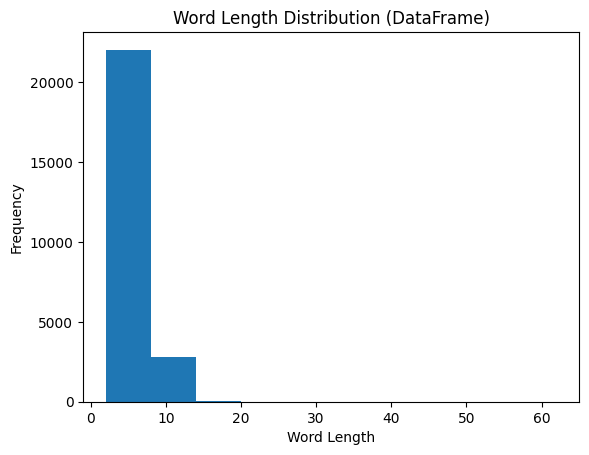

In [25]:
# Flatten all tokens from DataFrame
all_tokens = [w for row in df["tokens_nostop"] for w in row]

word_lengths = [len(w) for w in all_tokens]

print("Total tokens:", len(all_tokens))
print("Unique tokens:", len(set(all_tokens)))
print("Longest word:", max(all_tokens, key=len))
print("Shortest word:", min(all_tokens, key=len))
print("Average word length (overall):", round(sum(word_lengths) / len(word_lengths), 2))

# Plot word length distribution
plt.figure()
plt.hist(word_lengths)
plt.title("Word Length Distribution (DataFrame)")
plt.xlabel("Word Length")
plt.ylabel("Frequency")
plt.show()

Top 10 Most Frequent Words:
[('day', 244), ('good', 212), ('http', 176), ('got', 171), ('like', 166), ('get', 163), ('love', 160), ('go', 158), ('com', 139), ('know', 133)]


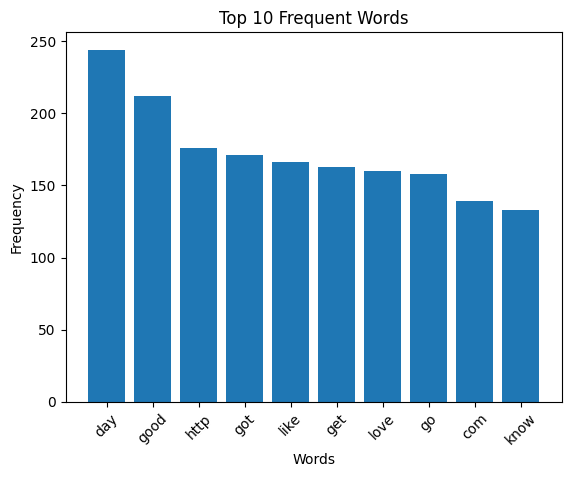

In [26]:
freq = Counter(all_tokens)

print("Top 10 Most Frequent Words:")
top10 = freq.most_common(10)
print(top10)

# Plot top 10 words
words = [w for w, c in top10]
counts = [c for w, c in top10]

plt.figure()
plt.bar(words, counts)
plt.title("Top 10 Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [27]:

df["bigrams"] = df["tokens_nostop"].apply(lambda x: list(ngrams(x, 2)))

# Flatten all bigrams
all_bigrams = [bg for row in df["bigrams"] for bg in row]
bigram_freq = Counter(all_bigrams)

print("Top 10 Bigrams:")
print(bigram_freq.most_common(10))

Top 10 Bigrams:
[(('gon', 'na'), 56), (('twitpic', 'com'), 55), (('http', 'twitpic'), 52), (('mother', 'day'), 39), (('mothers', 'day'), 36), (('wan', 'na'), 31), (('last', 'night'), 31), (('http', 'tinyurl'), 27), (('tinyurl', 'com'), 27), (('happy', 'mothers'), 24)]


In [28]:
df.head()

,textID,text,sentiment,text_lower,text_num_clean,text_web_clean,tokens,tokens_nostop,token_count,unique_token_count,avg_word_length,bigrams
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,last session of the day http://twitpic.com/67ezh,last session of the day http twitpic com ezh,last session of the day http twitpic com ezh,"[last, session, of, the, day, http, twitpic, c...","[last, session, day, http, twitpic, com, ezh]",7,7,4.428571,"[(last, session), (session, day), (day, http),..."
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,shanghai is also really exciting (precisely -...,shanghai is also really exciting precisely ...,shanghai is also really exciting precisely ...,"[shanghai, is, also, really, exciting, precise...","[shanghai, also, really, exciting, precisely, ...",12,12,5.916667,"[(shanghai, also), (also, really), (really, ex..."
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,"recession hit veronique branquinho, she has to...",recession hit veronique branquinho she has to...,recession hit veronique branquinho she has to...,"[recession, hit, veronique, branquinho, she, h...","[recession, hit, veronique, branquinho, quit, ...",7,7,6.714286,"[(recession, hit), (hit, veronique), (veroniqu..."
3,01082688c6,happy bday!,positive,happy bday!,happy bday,happy bday,"[happy, bday]","[happy, bday]",2,2,4.500000,"[(happy, bday)]"
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,http://twitpic.com/4w75p - i like it!!,http twitpic com w p i like it,http twitpic com w p i like it,"[http, twitpic, com, w, p, i, like, it]","[http, twitpic, com, like]",4,4,4.500000,"[(http, twitpic), (twitpic, com), (com, like)]"


In [29]:
df.to_csv("processed_test.csv", index=False)
print("Processed file saved as processed_test.csv")

Processed file saved as processed_test.csv
